# 03 — Honeypot Forensics (maximum-signal verification)

**Purpose:** before trusting any ranker, exhaustively verify *which candidates are honeypots* using **every field in the schema**, and dump the full contributing detail for each flag so nothing is hidden.

This notebook does NOT rank. It produces a **definitive honeypot list** (`outputs/honeypot_ids.csv`) that every later ranker hard-excludes, plus a calibration of `skill_assessment_scores` as a positive quality signal.

## Signal catalogue (grounded in `candidate_schema.json`)

| Class | Signal | Rule | Verdict |
|---|---|---|---|
| **HARD** | `date_mismatch` | job start→end months vs `duration_months` differ by >2 | honeypot |
| **HARD** | `yoe_mismatch` | Σ `duration_months` > `years_of_experience`×12 + 18 | honeypot |
| **HARD** | `skill_anomaly` | ≥4 expert/advanced skills with `duration_months = 0` | honeypot |
| **HARD** | `expert_assess_impossible` | a skill marked `expert` with assessment score <40 | honeypot |
| **SOFT** | `assess_lt_proficiency` | ≥2 advanced/expert skills with assessment <30 | suspicious (mostly stuffers) |
| **NOISE** | `skill_dur_gt_yoe` (13K), `signup_after_active` (7.5K), `yoe_gt_since_edu_start` (2.9K) | — | natural variance, NOT used |
| **CLEAN** | negative_duration, future_date, overlap_jobs, multi_current, is_current consistency, range violations, company mismatch | — | 0 fires — generator kept these consistent |

In [1]:
import json, warnings, statistics
from datetime import datetime
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')

CURRENT_DATE = datetime(2026, 6, 8)   # confirmed data-generation reference date
DATA_PATH = Path('../candidates.jsonl')
OUT_DIR   = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True)

def parse(d):
    try:
        return datetime.strptime(d, '%Y-%m-%d') if d else None
    except (ValueError, TypeError):
        return None

print(f'CURRENT_DATE = {CURRENT_DATE.date()}')

CURRENT_DATE = 2026-06-08


In [2]:
print('Loading 100K candidates...')
candidates = []
with open(DATA_PATH, encoding='utf-8') as f:
    for line in tqdm(f, desc='Reading'):
        line = line.strip()
        if line:
            candidates.append(json.loads(line))
print(f'Loaded {len(candidates):,}')

Loading 100K candidates...


Reading: 0it [00:00, ?it/s]

Loaded 100,000


## The comprehensive forensic function

Returns a **flat dict with every contributing value** for every check — so a flagged candidate shows *exactly* which job, which skill, which date caused the flag. Nothing is summarised away.

In [3]:
def forensic(c):
    cid     = c.get('candidate_id', '')
    prof    = c.get('profile', {}) or {}
    career  = c.get('career_history', []) or []
    skills  = c.get('skills', []) or []
    edu     = c.get('education', []) or []
    rs      = c.get('redrob_signals', {}) or {}
    yoe     = float(prof.get('years_of_experience', 0) or 0)

    hard, soft, noise = [], [], []
    detail = {}

    # ── HARD 1: date_mismatch ────────────────────────────────────────────────
    dm = []
    for i, j in enumerate(career):
        s, e = parse(j.get('start_date')), parse(j.get('end_date')) or CURRENT_DATE
        if s and e:
            actual = (e.year - s.year) * 12 + (e.month - s.month)
            claimed = j.get('duration_months', 0) or 0
            if abs(actual - claimed) > 2:
                dm.append(f"{j.get('company','?')}[{j.get('start_date')}->{j.get('end_date')}] claimed={claimed} actual={actual}")
    if dm:
        hard.append('date_mismatch'); detail['date_mismatch'] = ' ; '.join(dm[:4])

    # ── HARD 2: yoe_mismatch ─────────────────────────────────────────────────
    total_mo = sum(j.get('duration_months', 0) or 0 for j in career)
    if total_mo > yoe * 12 + 18:
        hard.append('yoe_mismatch')
        detail['yoe_mismatch'] = f'career_months={total_mo} ({total_mo/12:.1f}y) vs claimed_yoe={yoe}'

    # ── HARD 3: skill_anomaly (>=4 expert/adv, 0 duration) ───────────────────
    ez = [s.get('name','?') for s in skills
          if (s.get('proficiency') or '').lower() in ('expert','advanced')
          and (s.get('duration_months',0) or 0) == 0]
    if len(ez) >= 4:
        hard.append('skill_anomaly'); detail['skill_anomaly'] = f'{len(ez)} expert/adv@0mo: ' + ', '.join(ez[:6])

    # ── HARD 4: expert with impossible assessment (<40) ──────────────────────
    sas = rs.get('skill_assessment_scores', {}) or {}
    pbn = {(s.get('name') or '').lower(): (s.get('proficiency') or '').lower() for s in skills}
    expert_imposs = [f'{sk}={sc}' for sk, sc in sas.items()
                     if pbn.get((sk or '').lower()) == 'expert'
                     and isinstance(sc,(int,float)) and sc < 40]
    if expert_imposs:
        hard.append('expert_assess_impossible'); detail['expert_assess_impossible'] = ', '.join(expert_imposs)

    # ── SOFT: >=2 advanced/expert skills with assessment <30 ─────────────────
    low_adv = [f'{sk}={sc}({pbn.get((sk or "").lower())})' for sk, sc in sas.items()
               if pbn.get((sk or '').lower()) in ('advanced','expert')
               and isinstance(sc,(int,float)) and sc < 30]
    if len(low_adv) >= 2:
        soft.append('assess_lt_proficiency'); detail['assess_lt_proficiency'] = ', '.join(low_adv[:6])

    # ── NOISE (tracked but never used for exclusion) ─────────────────────────
    max_skill_dur = max((s.get('duration_months',0) or 0 for s in skills), default=0)
    if yoe > 0 and max_skill_dur > yoe * 12 + 6:
        noise.append('skill_dur_gt_yoe')
    su, la = parse(rs.get('signup_date')), parse(rs.get('last_active_date'))
    if su and la and su > la:
        noise.append('signup_after_active')
    syrs = [ed.get('start_year') for ed in edu if ed.get('start_year')]
    if syrs and yoe > (CURRENT_DATE.year - min(syrs)) + 2:
        noise.append('yoe_gt_since_edu_start')

    # ── assessment positive-signal aggregates (for ranker reuse) ─────────────
    ai_scores = [sc for sk, sc in sas.items() if isinstance(sc,(int,float))]
    return {
        'candidate_id': cid,
        'title': prof.get('current_title',''),
        'yoe': yoe,
        'country': prof.get('country',''),
        'n_jobs': len(career),
        'n_skills': len(skills),
        'n_assessments': len(sas),
        'mean_assessment': round(statistics.mean(ai_scores),1) if ai_scores else None,
        'max_assessment': max(ai_scores) if ai_scores else None,
        'is_hard_honeypot': bool(hard),
        'is_soft_suspect': bool(soft),
        'hard_flags': '|'.join(hard),
        'soft_flags': '|'.join(soft),
        'noise_flags': '|'.join(noise),
        'detail_date_mismatch':            detail.get('date_mismatch',''),
        'detail_yoe_mismatch':             detail.get('yoe_mismatch',''),
        'detail_skill_anomaly':            detail.get('skill_anomaly',''),
        'detail_expert_assess_impossible': detail.get('expert_assess_impossible',''),
        'detail_assess_lt_proficiency':    detail.get('assess_lt_proficiency',''),
    }

print('forensic() defined.')

forensic() defined.


In [4]:
rows = [forensic(c) for c in tqdm(candidates, desc='Forensic scan')]
fdf = pd.DataFrame(rows)
print(f'Forensic table: {fdf.shape}')
print(f"HARD honeypots: {fdf['is_hard_honeypot'].sum()}")
print(f"SOFT suspects:  {fdf['is_soft_suspect'].sum()}")

Forensic scan:   0%|          | 0/100000 [00:00<?, ?it/s]

Forensic table: (100000, 19)
HARD honeypots: 53
SOFT suspects:  45


## Signal frequency — classify each into HARD / SOFT / NOISE

In [5]:
def count_flags(col):
    c = Counter()
    for v in fdf[col]:
        for f in str(v).split('|'):
            if f: c[f] += 1
    return c

print('HARD flags:')
for f, n in count_flags('hard_flags').most_common():
    print(f'  {n:6,}  {f}')
print('\nSOFT flags:')
for f, n in count_flags('soft_flags').most_common():
    print(f'  {n:6,}  {f}')
print('\nNOISE flags (NOT used for exclusion):')
for f, n in count_flags('noise_flags').most_common():
    print(f'  {n:6,}  {f}')

print(f"\nDefinitive HARD honeypot count: {fdf['is_hard_honeypot'].sum()}")
print(f"HARD + SOFT union:              {(fdf['is_hard_honeypot'] | fdf['is_soft_suspect']).sum()}")

HARD flags:
      35  date_mismatch
      24  yoe_mismatch
      13  skill_anomaly
       1  expert_assess_impossible

SOFT flags:
      45  assess_lt_proficiency

NOISE flags (NOT used for exclusion):
  13,449  skill_dur_gt_yoe
   7,496  signup_after_active
   2,888  yoe_gt_since_edu_start

Definitive HARD honeypot count: 53
HARD + SOFT union:              98


## Full forensic dump — every HARD honeypot with its contributing evidence

In [6]:
hard_df = fdf[fdf['is_hard_honeypot']].copy()
cols = ['candidate_id','title','yoe','hard_flags',
        'detail_date_mismatch','detail_yoe_mismatch','detail_skill_anomaly','detail_expert_assess_impossible']
print(f'=== ALL {len(hard_df)} HARD HONEYPOTS — FULL EVIDENCE ===')
for _, r in hard_df.iterrows():
    print(f"\n{r['candidate_id']} | {r['title']} | yoe={r['yoe']} | flags={r['hard_flags']}")
    for d in ['detail_date_mismatch','detail_yoe_mismatch','detail_skill_anomaly','detail_expert_assess_impossible']:
        if r[d]:
            print(f"    {d.replace('detail_',''):26s}: {r[d]}")

=== ALL 53 HARD HONEYPOTS — FULL EVIDENCE ===

CAND_0001610 | Machine Learning Engineer | yoe=3.0 | flags=yoe_mismatch
    yoe_mismatch              : career_months=61 (5.1y) vs claimed_yoe=3.0

CAND_0003430 | Business Analyst | yoe=13.7 | flags=date_mismatch
    date_mismatch             : Infosys[2025-03-03->None] claimed=11 actual=15

CAND_0005291 | Business Analyst | yoe=12.8 | flags=date_mismatch
    date_mismatch             : Hooli[2023-09-10->None] claimed=11 actual=33

CAND_0007353 | Frontend Engineer | yoe=9.9 | flags=date_mismatch|yoe_mismatch
    date_mismatch             : Wayne Enterprises[2023-09-10->None] claimed=166 actual=33
    yoe_mismatch              : career_months=251 (20.9y) vs claimed_yoe=9.9

CAND_0007413 | Business Analyst | yoe=13.3 | flags=date_mismatch
    date_mismatch             : Globex Inc[2022-11-14->None] claimed=16 actual=43

CAND_0008960 | Graphic Designer | yoe=10.3 | flags=date_mismatch|yoe_mismatch
    date_mismatch             : Stark Industr

## SOFT suspects — assessment vs proficiency (mostly keyword stuffers)

In [7]:
soft_df = fdf[fdf['is_soft_suspect'] & ~fdf['is_hard_honeypot']].copy()
print(f'SOFT-only suspects (not already HARD): {len(soft_df)}')
print('\nTitle distribution of soft suspects (confirms stuffer pattern):')
print(soft_df['title'].value_counts().head(15).to_string())
print('\nSample evidence:')
for _, r in soft_df.head(10).iterrows():
    print(f"  {r['candidate_id']} | {r['title']:22s} yoe={r['yoe']:4} | {r['detail_assess_lt_proficiency']}")

SOFT-only suspects (not already HARD): 45

Title distribution of soft suspects (confirms stuffer pattern):
title
Mobile Developer        11
.NET Developer           7
Software Engineer        7
Cloud Engineer           6
Frontend Engineer        4
QA Engineer              4
Full Stack Developer     3
DevOps Engineer          2
Java Developer           1

Sample evidence:
  CAND_0000899 | Full Stack Developer   yoe= 4.1 | GANs=25.9(advanced), CNN=25.9(advanced)
  CAND_0001850 | QA Engineer            yoe= 5.7 | Machine Learning=26.2(advanced), QLoRA=25.4(advanced)
  CAND_0005536 | Cloud Engineer         yoe= 9.7 | Learning to Rank=29.3(advanced), Diffusion Models=25.5(advanced)
  CAND_0006681 | Full Stack Developer   yoe= 9.1 | TTS=26.3(advanced), OpenSearch=29.1(advanced)
  CAND_0009988 | Cloud Engineer         yoe= 9.9 | Feature Engineering=26.0(advanced), NLP=28.0(advanced)
  CAND_0010034 | Mobile Developer       yoe= 3.5 | Diffusion Models=26.0(advanced), Python=25.3(advanced)
  CAN

## `skill_assessment_scores` as a POSITIVE quality signal

This is the lever that breaks the flat-0.7000 ties in the ranker: a genuine AI engineer with high assessment scores should outrank one with none / low scores.

In [8]:
# Coverage and calibration of assessment scores by proficiency
buckets = defaultdict(list)
for c in candidates:
    rs = c.get('redrob_signals', {}) or {}
    sas = rs.get('skill_assessment_scores', {}) or {}
    pbn = {(s.get('name') or '').lower(): (s.get('proficiency') or '').lower() for s in c.get('skills', [])}
    for sk, sc in sas.items():
        p = pbn.get((sk or '').lower())
        if p and isinstance(sc,(int,float)):
            buckets[p].append(sc)

print('Assessment score distribution by claimed proficiency:')
for p in ['beginner','intermediate','advanced','expert']:
    v = buckets.get(p, [])
    if v:
        v.sort()
        print(f"  {p:13s} n={len(v):6d}  mean={statistics.mean(v):5.1f}  p10={v[len(v)//10]:5.1f}  p90={v[int(len(v)*0.9)]:5.1f}")

cov = fdf['n_assessments'].gt(0).mean()
print(f'\nCandidates with >=1 assessment score: {cov*100:.1f}%')
print(f"Candidates with >=1 assessment among Senior AI/ML titles will use this as a tie-breaker bonus.")

Assessment score distribution by claimed proficiency:
  intermediate  n=     8  mean= 52.8  p10= 39.6  p90= 74.1
  advanced      n= 35613  mean= 52.8  p10= 31.0  p90= 73.8
  expert        n=   229  mean= 71.4  p10= 53.9  p90= 88.7

Candidates with >=1 assessment score: 24.2%
Candidates with >=1 assessment among Senior AI/ML titles will use this as a tie-breaker bonus.


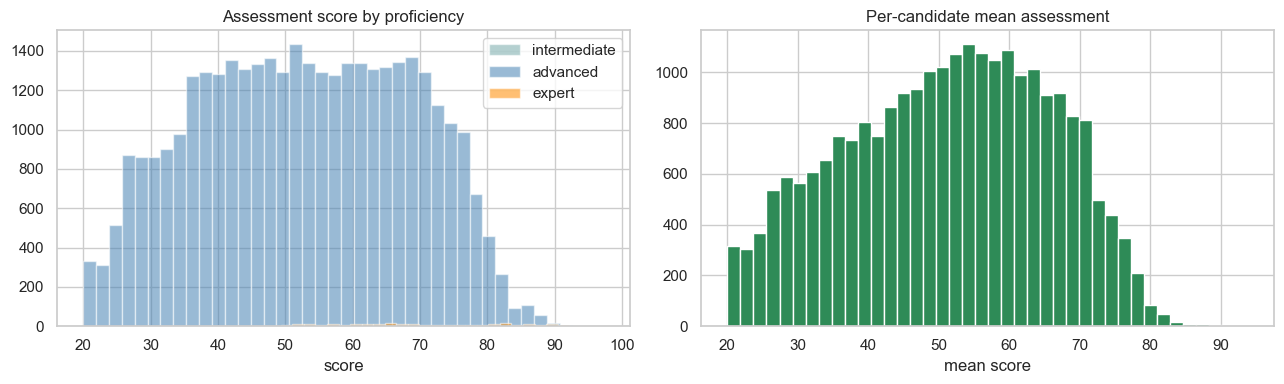

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for p, col in [('beginner','#bbb'),('intermediate','#7aa'),('advanced','steelblue'),('expert','darkorange')]:
    v = buckets.get(p, [])
    if v:
        axes[0].hist(v, bins=40, alpha=0.55, label=p, color=col)
axes[0].set_title('Assessment score by proficiency'); axes[0].set_xlabel('score'); axes[0].legend()

mean_scores = fdf[fdf['mean_assessment'].notna()]['mean_assessment']
axes[1].hist(mean_scores, bins=40, color='seagreen')
axes[1].set_title('Per-candidate mean assessment'); axes[1].set_xlabel('mean score')
plt.tight_layout(); plt.savefig(OUT_DIR / 'hp_assessment_calibration.png', dpi=120); plt.show()

## Export — definitive honeypot list + assessment features for the ranker

In [10]:
# 1) HARD honeypot ids — every later ranker hard-excludes these (score = 0)
hp_ids = fdf[fdf['is_hard_honeypot']][['candidate_id','hard_flags']].copy()
hp_ids.to_csv(OUT_DIR / 'honeypot_ids.csv', index=False)
print(f"Saved {len(hp_ids)} HARD honeypot ids -> outputs/honeypot_ids.csv")

# 2) Soft suspects (for optional penalty / audit)
soft_ids = fdf[fdf['is_soft_suspect'] & ~fdf['is_hard_honeypot']][['candidate_id','soft_flags','detail_assess_lt_proficiency']]
soft_ids.to_csv(OUT_DIR / 'soft_suspect_ids.csv', index=False)
print(f"Saved {len(soft_ids)} soft suspects -> outputs/soft_suspect_ids.csv")

# 3) Full forensic table + assessment features (parquet, reused by ranker)
fdf.to_parquet(OUT_DIR / 'forensics_full.parquet', index=False)
print(f"Saved full forensic table -> outputs/forensics_full.parquet  {fdf.shape}")

Saved 53 HARD honeypot ids -> outputs/honeypot_ids.csv
Saved 45 soft suspects -> outputs/soft_suspect_ids.csv


Saved full forensic table -> outputs/forensics_full.parquet  (100000, 19)


In [11]:
print('='*64)
print('HONEYPOT FORENSICS — CONCLUSIONS')
print('='*64)
n_hard = fdf['is_hard_honeypot'].sum()
n_soft = (fdf['is_soft_suspect'] & ~fdf['is_hard_honeypot']).sum()
print(f'HARD honeypots (exclude, score=0):      {n_hard}')
print(f'SOFT suspects  (penalise/audit):        {n_soft}')
print(f'HARD + SOFT union:                      {n_hard + n_soft}')
print()
print('Mechanism confirmed:')
print('  - honeypots created ONLY via date / yoe / skill-duration / expert-assessment impossibilities')
print('  - all other impossibility dimensions are 0 (data internally consistent)')
print('  - skill_dur/signup/edu signals are natural variance (1000s) -> NOT used')
print()
print('For the ranker:')
print('  - hard-exclude honeypot_ids.csv')
print('  - use skill_assessment_scores as a POSITIVE tie-breaker (expert real >> expert claimed)')
print('  - soft suspects are mostly keyword stuffers, already gated by the title multiplier')

HONEYPOT FORENSICS — CONCLUSIONS
HARD honeypots (exclude, score=0):      53
SOFT suspects  (penalise/audit):        45
HARD + SOFT union:                      98

Mechanism confirmed:
  - honeypots created ONLY via date / yoe / skill-duration / expert-assessment impossibilities
  - all other impossibility dimensions are 0 (data internally consistent)
  - skill_dur/signup/edu signals are natural variance (1000s) -> NOT used

For the ranker:
  - hard-exclude honeypot_ids.csv
  - use skill_assessment_scores as a POSITIVE tie-breaker (expert real >> expert claimed)
  - soft suspects are mostly keyword stuffers, already gated by the title multiplier
